**Table of contents**<a id='toc0_'></a>

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import time
from collections import namedtuple

import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst
from consav.linear_interp import interp_1d, interp_1d_vec

# Simulation and aggregation

The EGM gives us policy functions: what *one* household does in every state. To close the model in the next
lecture we need aggregates: total savings $A_t^{hh}$ and total consumption $C_t^{hh}$ across *all* households.
Those depend on how many households sit in each state, that is, on the distribution over $(z_t, a_{t-1})$.

This notebook simulates that distribution forward in two ways:

1. **Monte Carlo:** simulate a large sample of households and average.
2. **The histogram method** (Young, 2010): iterate on the distribution itself, as an array of probabilities.

Then we aggregate. The forward step we end up with, `simulate_hh_forwards`, is the second half of the household
block in `GEModelTools`; the first half, `solve_hh_backwards`, we built in the previous notebook.

## The model

Exactly the model of the previous notebook, solved with the same EGM code, here condensed into one cell.

In [2]:
Parameters = namedtuple('Parameters',
    'beta sigma r w rho_z sigma_psi Nz Na a_min a_max a_grid z_grid z_trans z_ergodic')

def setup():
    """ baseline parameters """

    # preferences
    beta = 0.96
    sigma = 2.0

    # prices
    r = 0.02
    w = 1.0

    # income
    rho_z = 0.95
    sigma_psi = 0.10
    Nz = 7
    z_grid,z_trans,z_ergodic,_,_ = log_rouwenhorst(rho_z,sigma_psi,Nz)

    # grids
    Na = 300
    a_min = 0.0
    a_max = 100.0
    a_grid = equilogspace(a_min,a_max,Na)

    return Parameters(beta,sigma,r,w,rho_z,sigma_psi,Nz,Na,a_min,a_max,a_grid,z_grid,z_trans,z_ergodic)

@nb.njit(parallel=True)
def solve_hh_backwards(par,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c):
    """ solve backwards with vbeg_a from previous iteration (here vbeg_a_plus) """

    # a. solve step
    for i_z in nb.prange(par.Nz):

        c_endo = (par.beta*vbeg_a_plus[i_z])**(-1/par.sigma)
        a_endo = (c_endo + par.a_grid - w*par.z_grid[i_z])/(1+r)
        interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_z])
        a[i_z,:] = np.fmax(a[i_z,:],0.0)
        c[i_z] = par.a_grid*(1+r) + w*par.z_grid[i_z] - a[i_z]

    # b. expectation step
    v_a = (1+r)*c**(-par.sigma)
    vbeg_a[:] = z_trans@v_a

def solve_hh_ss(par,r,w,max_iter=10_000,tol=1e-10):
    """ solve the household problem in the infinite horizon """

    # a. allocate
    vbeg_a = np.zeros((par.Nz,par.Na))
    a = np.zeros((par.Nz,par.Na))
    c = np.zeros((par.Nz,par.Na))

    # b. initial guess: a(z,a_) = a_, so consumption is the annuity value
    c_guess = r*par.a_grid[np.newaxis,:] + w*par.z_grid[:,np.newaxis]
    vbeg_a_plus = par.z_trans@((1+r)*c_guess**(-par.sigma))

    # c. iterate
    for it in range(max_iter):

        solve_hh_backwards(par,par.z_trans,r,w,vbeg_a_plus,vbeg_a,a,c)

        if np.max(np.abs(vbeg_a-vbeg_a_plus)) < tol: break
        vbeg_a_plus[:] = vbeg_a

    return c,a,vbeg_a

par = setup()
c,a,vbeg_a = solve_hh_ss(par,par.r,par.w)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Monte Carlo

The direct approach. Simulate $N$ households:

- **Initial state:** $a_{i,-1} = 0$ and $z_{i,-1}$ drawn from the ergodic distribution.
- **Each period:** draw $z_{it}$ given $z_{it-1}$ from the transition matrix, then read savings off the policy
  function, $a_{it} = a^*(z_{it}, a_{it-1})$, with linear interpolation.

After enough periods the cross-section $\{z_{it}, a_{it}\}_{i=0}^{N-1}$ no longer changes (as a distribution):
it has converged to the *stationary distribution*. Aggregates are then sample averages, e.g.
$A^{hh}_t = \frac{1}{N}\sum_i a_{it}$, and the law of large numbers says they converge to the truth as
$N \rightarrow \infty$.

In [3]:
@nb.njit
def simulate_mc(par,a_pol,z_trans_cumsum,i_z,a_sim,A_t):
    """ simulate the panel forward, storing aggregate assets per period """

    N = a_sim.size
    T_sim = A_t.size

    for t in range(T_sim):
        for i in range(N):
            i_z[i] = np.searchsorted(z_trans_cumsum[i_z[i]],np.random.random())
            a_sim[i] = interp_1d(par.a_grid,a_pol[i_z[i]],a_sim[i])
        A_t[t] = np.mean(a_sim)

def run_mc(par,a_pol,N,T_sim,seed=1917):
    """ allocate, draw the initial state and simulate """

    np.random.seed(seed)
    z_trans_cumsum = np.cumsum(par.z_trans,axis=1)
    i_z = np.random.choice(par.Nz,size=N,p=par.z_ergodic)
    a_sim = np.zeros(N)
    A_t = np.zeros(T_sim)
    simulate_mc(par,a_pol,z_trans_cumsum,i_z,a_sim,A_t)

    return i_z,a_sim,A_t

simulation time: 1.4 secs


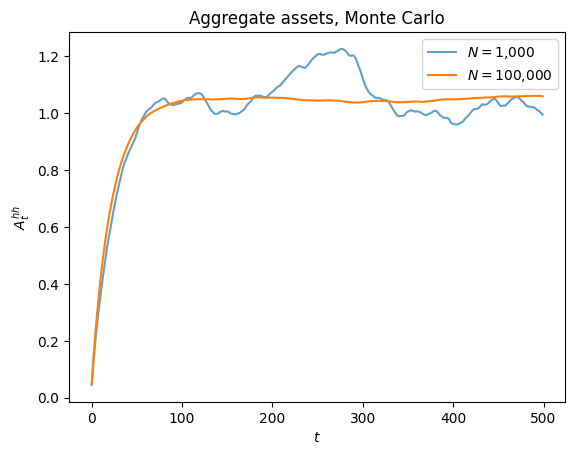

In [4]:
T_sim = 500

t0 = time.time()
i_z_small,a_small,A_t_small = run_mc(par,a,1_000,T_sim)
i_z_sim,a_sim,A_t = run_mc(par,a,100_000,T_sim)
print(f'simulation time: {time.time()-t0:.1f} secs')

plt.plot(A_t_small,label='$N = 1{,}000$',alpha=0.7)
plt.plot(A_t,label='$N = 100{,}000$')
plt.title('Aggregate assets, Monte Carlo')
plt.xlabel('$t$')
plt.ylabel('$A_t^{hh}$')
plt.legend()
plt.savefig('figs/sim_mc_A.pdf')
plt.show()

Two things to see. First, the **burn-in**: starting everyone at $a_{-1}=0$, aggregate assets take a couple of
hundred periods to reach their stationary level. Second, the **noise**: even after convergence, $A_t^{hh}$ keeps
fluctuating, and the fluctuations only die out slowly as $N$ grows.

How slowly? The central limit theorem says the sampling error is proportional to $1/\sqrt{N}$: quadrupling the
number of households halves the error. We can check that by splitting our big cross-section into disjoint
subsamples of size $N$ and computing the standard deviation of the estimate across subsamples.

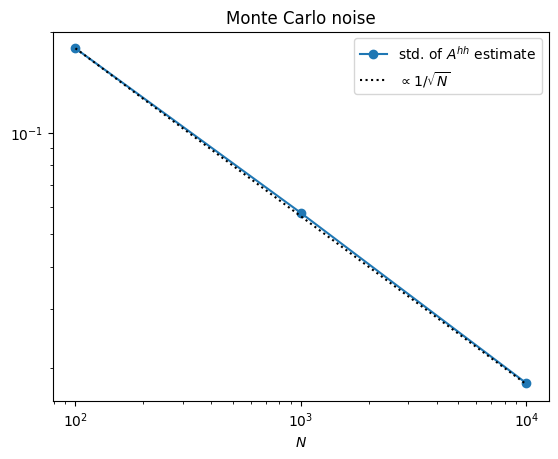

In [5]:
Ns = np.array([100,1_000,10_000])
stds = np.array([np.std(a_sim.reshape(-1,N).mean(axis=1)) for N in Ns])

plt.loglog(Ns,stds,'-o',label='std. of $A^{hh}$ estimate')
plt.loglog(Ns,stds[0]*np.sqrt(Ns[0]/Ns),':',color='black',label=r'$\propto 1/\sqrt{N}$')
plt.title('Monte Carlo noise')
plt.xlabel('$N$')
plt.legend()
plt.savefig('figs/sim_mc_noise.pdf')
plt.show()

This is a real problem for what comes next. In the next lecture, the interest rate has to clear the asset
market: we will be root-finding on something like $A^{hh}(r) - K(r) = 0$. With Monte Carlo, $A^{hh}(r)$ carries
random noise of order $1/\sqrt{N}$, so the market clearing condition can never be solved to a tighter tolerance
than that, no matter how good the root-finder. We need the *exact* distribution implied by the policy function,
not a sample from it.

## The histogram method

Young (2010): stop tracking households, track *probability mass*. The distribution becomes an array
$\boldsymbol{D}$ over the grids $\mathcal{G}_z \times \mathcal{G}_a$, summing to one, a *histogram*. Both
transitions then become deterministic:

**1. The productivity transition is a matrix product.** With $\underline{\boldsymbol{D}}_t$ the
beginning-of-period distribution over $(z_{t-1}, a_{t-1})$,

$$
\boldsymbol{D}_t(z^{i_z}, a^{i_{a-}}) = \sum_{i_{z-}} \pi_{i_{z-},i_z} \underline{\boldsymbol{D}}_t(z^{i_{z-}}, a^{i_{a-}})
\quad\Leftrightarrow\quad \boldsymbol{D}_t = \Pi_z' \underline{\boldsymbol{D}}_t
$$

**2. The savings transition is a lottery.** All mass at $(z^{i_z}, a^{i_{a-}})$ saves
$a^* = a^*(z^{i_z}, a^{i_{a-}})$, which generically falls *between* two grid points. Find $i$ such that
$a^i \leq a^* \leq a^{i+1}$ and split the mass between the neighbors,

$$
\omega = \frac{a^{i+1} - a^*}{a^{i+1} - a^i} \in [0,1]
$$

with share $\omega$ to $a^i$ and $1-\omega$ to $a^{i+1}$. The split is chosen so the *mean* of the lottery is
exactly $a^*$: aggregate savings are not distorted by putting the distribution on a grid.

The policy function does not change over time here, so the lottery can be computed once and stored as an index
and a weight per grid point.

In [6]:
# a. find the left neighbor of a*(z,a_) on the asset grid
pol_indices = np.zeros((par.Nz,par.Na),dtype=np.int64)
pol_weights = np.zeros((par.Nz,par.Na))

for i_z in range(par.Nz):

    i = np.searchsorted(par.a_grid,a[i_z],side='right') - 1
    i = np.clip(i,0,par.Na-2)

    # b. share omega to i, 1-omega to i+1
    pol_indices[i_z] = i
    pol_weights[i_z] = (par.a_grid[i+1]-a[i_z])/(par.a_grid[i+1]-par.a_grid[i])

assert np.all((pol_weights >= 0.0) & (pol_weights <= 1.0))

One period forward is then two loops over the grid, no random numbers anywhere:

In [7]:
@nb.njit
def simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus):
    """ one period forward: productivity transition, then the savings lottery """

    # a. productivity transition
    D = par.z_trans.T@Dbeg

    # b. savings lottery
    Dbeg_plus[:] = 0.0
    for i_z in range(par.Nz):
        for i_a in range(par.Na):

            i = pol_indices[i_z,i_a]
            omega = pol_weights[i_z,i_a]
            Dbeg_plus[i_z,i] += omega*D[i_z,i_a]
            Dbeg_plus[i_z,i+1] += (1-omega)*D[i_z,i_a]

    return D

Start from the same initial condition as the Monte Carlo, everyone at $a_{-1} = 0$ with $z_{-1}$ ergodic, and
iterate. We plot the CDF of assets after a few different numbers of periods:

simulation time: 0.19 secs


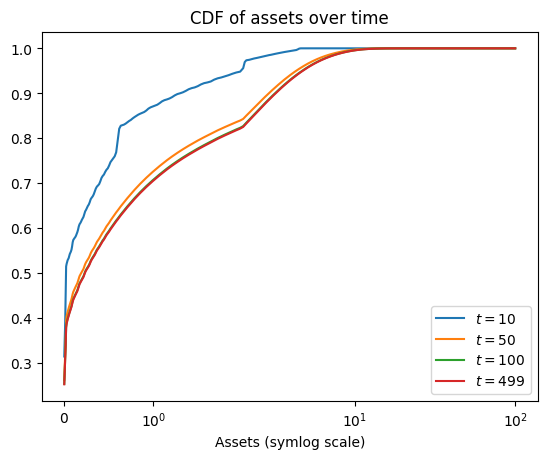

In [8]:
# a. initial distribution: all mass at a = 0
Dbeg = np.zeros((par.Nz,par.Na))
Dbeg[:,0] = par.z_ergodic

# b. iterate forward, plotting snapshots
Dbeg_plus = np.zeros_like(Dbeg)

t0 = time.time()
for t in range(T_sim):

    if t in [10,50,100,T_sim-1]:
        plt.plot(par.a_grid,np.cumsum(Dbeg.sum(axis=0)),label=f'$t = {t}$')

    simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus)
    Dbeg,Dbeg_plus = Dbeg_plus,Dbeg

print(f'simulation time: {time.time()-t0:.2f} secs')

plt.xscale('symlog')
plt.title('CDF of assets over time')
plt.xlabel('Assets (symlog scale)')
plt.legend()
plt.savefig('figs/sim_dist_convergence.pdf')
plt.show()

Same $T$ as the Monte Carlo, a fraction of the time, and each period is *exact* given the previous
distribution. The distribution converges: after a few hundred periods the CDF stops moving. As with the policy
functions, we can make that the stopping rule and iterate to the **stationary distribution**:

In [9]:
def simulate_hh_ss(par,pol_indices,pol_weights,max_iter=100_000,tol=1e-13):
    """ iterate the forward step until the distribution stops moving """

    Dbeg = np.zeros((par.Nz,par.Na))
    Dbeg[:,0] = par.z_ergodic
    Dbeg_plus = np.zeros_like(Dbeg)

    for it in range(max_iter):

        D = simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus)

        if np.max(np.abs(Dbeg_plus-Dbeg)) < tol: break
        Dbeg,Dbeg_plus = Dbeg_plus,Dbeg

    return Dbeg_plus,D,it

t0 = time.time()
Dbeg_ss,D_ss,it = simulate_hh_ss(par,pol_indices,pol_weights)
print(f'converged in {it} iterations, {time.time()-t0:.2f} secs')
print(f'total mass: {np.sum(Dbeg_ss):.12f}')

converged in 526 iterations, 0.01 secs
total mass: 1.000000000000


Does it agree with the Monte Carlo? Compare the CDF of end-of-period assets: the empirical CDF of the simulated
cross-section against the cumulative sum of the histogram.

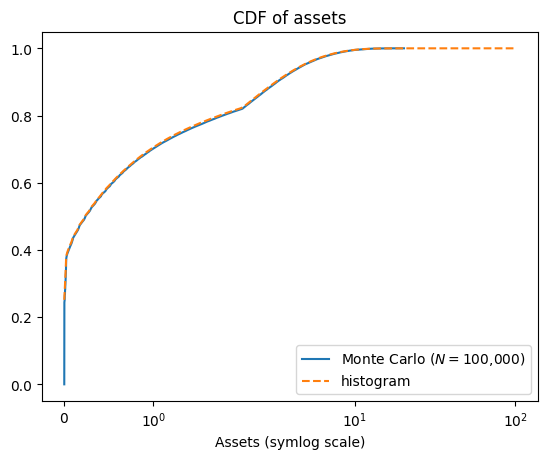

In [10]:
plt.plot(np.sort(a_sim),np.linspace(0,1,a_sim.size),label='Monte Carlo ($N = 100{,}000$)')
plt.plot(par.a_grid,np.cumsum(Dbeg_ss.sum(axis=0)),'--',label='histogram')
plt.xscale('symlog')
plt.title('CDF of assets')
plt.xlabel('Assets (symlog scale)')
plt.legend()
plt.savefig('figs/sim_mc_vs_hist.pdf')
plt.show()

The two methods agree on the distribution. The histogram is the exact limit the Monte Carlo is trying to reach
by brute force.

One caveat: the histogram lives *on the grid*. Each policy function value is replaced by a two-point lottery, so
the distribution is only as fine as $\mathcal{G}_a$, and objects that depend on the distribution respond to a
parameter change in small discrete jumps. In practice a few hundred grid points make this a non-issue.

## Aggregation

With the distribution in hand, aggregates are sums over the grid,

$$
A^{hh} = \sum_{i_z}\sum_{i_{a-}} \boldsymbol{D}(z^{i_z},a^{i_{a-}}) \, a^*(z^{i_z},a^{i_{a-}}), \qquad
C^{hh} = \sum_{i_z}\sum_{i_{a-}} \boldsymbol{D}(z^{i_z},a^{i_{a-}}) \, c^*(z^{i_z},a^{i_{a-}})
$$

where $\boldsymbol{D} = \Pi_z' \underline{\boldsymbol{D}}$ is the distribution *after* the productivity draw,
so it lines up with the states the policy functions are indexed by.

In [11]:
A_hh = np.sum(D_ss*a)
C_hh = np.sum(D_ss*c)

print(f'A_hh (histogram):   {A_hh:.4f}')
print(f'A_hh (Monte Carlo): {A_t[-1]:.4f}')
print(f'C_hh (histogram):   {C_hh:.4f}')

A_hh (histogram):   1.0501
A_hh (Monte Carlo): 1.0597
C_hh (histogram):   1.0210


Two checks. In the stationary distribution, aggregating the budget constraint gives
$C^{hh} = r A^{hh} + w$, since $\mathbb{E}[z] = 1$ and aggregate assets are constant:

In [12]:
print(f'C_hh:        {C_hh:.8f}')
print(f'r*A_hh + w:  {par.r*A_hh + par.w:.8f}')

C_hh:        1.02100258
r*A_hh + w:  1.02100258


And the aggregate MPC. In lecture 02 the PIH said around $2\%$; the data said $40$-$50\%$. What does the model
say? Weight the MPC at each grid point by the mass of households sitting there:

In [13]:
MPC = np.zeros((par.Nz,par.Na))
MPC[:,:-1] = (c[:,1:]-c[:,:-1])/((1+par.r)*(par.a_grid[1:]-par.a_grid[:-1]))
MPC[:,-1] = MPC[:,-2]

MPC_hh = np.sum(D_ss*MPC)
print(f'aggregate MPC: {MPC_hh:.3f}')
print(f'PIH, r/(1+r):  {par.r/(1+par.r):.3f}')

aggregate MPC: 0.326
PIH, r/(1+r):  0.020


The aggregate MPC is an order of magnitude above the PIH, because a lot of mass sits at low asset levels where
the MPC is high. This number is a property of the *distribution*, not of any single household, which is exactly
why we needed this notebook.

## Summary

Solving the household block is now a fixed two-step recipe:

1. **Backward:** iterate `solve_hh_backwards` (EGM) until the policy functions converge.
2. **Forward:** build the lottery, iterate `simulate_hh_forwards` (histogram) until the distribution converges.
3. **Aggregate:** $A^{hh} = \sum \boldsymbol{D} \, a^*$ and $C^{hh} = \sum \boldsymbol{D} \, c^*$.

Everything is deterministic, fast, and exact up to the grids. In the next lecture `GEModelTools` runs precisely
this recipe for us, and the prices $r$ and $w$, fixed here, become equilibrium objects that make the aggregates
consistent with firms and market clearing.